# Preparación para Control: Análisis de Datos e Inferencia Estadística

Este cuaderno contiene un resumen de los conceptos fundamentales y una serie de ejercicios prácticos para aplicar técnicas de estadística descriptiva y visualización utilizando Python.

---

## 1. Resumen de Conceptos Clave

### Fundamentos
- **Población:** Conjunto total de individuos sobre el que queremos concluir.
- **Muestra:** Subconjunto representativo de la población sobre el cual trabajamos.
- **Variable:** Característica que varía entre los individuos (puede ser numérica o categórica).
- **Parámetro vs. Estadístico:** El parámetro describe a la población; el estadístico describe a la muestra.

### Estadística Descriptiva
- **Medidas de Tendencia Central:**
  - *Media (Promedio):* Sensible a valores atípicos (outliers).
  - *Mediana:* Valor central que divide los datos al 50%. Robusta ante outliers.
  - *Moda:* El valor más frecuente.
- **Medidas de Dispersión:**
  - *Rango:* Máximo - Mínimo.
  - *Desviación Estándar:* Qué tan alejados están, en promedio, los datos respecto a la media.
  - *Cuartiles (Percentiles 25, 50, 75):* Dividen los datos en cuatro partes iguales. Útiles para los Boxplots.

### Análisis Exploratorio de Datos (EDA)
Pasos típicos con `pandas`:
1. `df.info()`: Revisar tipos de datos y valores nulos.
2. `df.describe()`: Obtener estadísticas descriptivas rápidas.
3. Visualización: Histogramas para ver distribuciones, Boxplots para dispersión/outliers y Scatter plots para relaciones entre variables numéricas.

## 2. Preparación del Entorno y Datos

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")

# Generar datos simulados (N = 300 pacientes)
np.random.seed(42)
n = 300

datos = {
    'Edad': np.random.normal(45, 15, n).astype(int),
    'Sexo': np.random.choice(['Femenino', 'Masculino'], n, p=[0.55, 0.45]),
    'IMC': np.random.normal(27.5, 5, n).round(1),
    'Presion_Sistolica': np.random.normal(125, 18, n).astype(int),
    'Glucosa_Ayunas': np.random.normal(105, 25, n).astype(int)
}

df = pd.DataFrame(datos)

# Limpiando valores imposibles (ej: edades negativas si las hubiera)
df = df[df['Edad'] > 18].copy()

# Creando una variable categórica basada en el IMC
df['Riesgo_Cardiovascular'] = pd.cut(
    df['IMC'], 
    bins=[0, 24.9, 29.9, 100], 
    labels=['Bajo', 'Moderado', 'Alto']
)

# Mostramos las primeras 5 filas
df.head()

,Edad,Sexo,IMC,Presion_Sistolica,Glucosa_Ayunas,Riesgo_Cardiovascular
0,52,Femenino,19.2,115,132,Bajo
1,42,Femenino,30.2,150,134,Alto
2,54,Masculino,24.2,166,120,Bajo
3,67,Masculino,30.4,118,76,Alto
4,41,Masculino,23.7,116,145,Bajo


## 3. Ejercicios Prácticos

### Ejercicio 1: Exploración Básica
Utiliza los métodos de Pandas para obtener un resumen estadístico de las variables numéricas del DataFrame y coméntame qué notas sobre la columna `Presion_Sistolica` (¿cuál es su media y desviación estándar?).

In [37]:
df.info() #Para obtener las variables que sean numéricas

estadisticas_edad = df["Edad"].describe()
estadisticas_imc = df["IMC"].describe()
estadisticas_presion = df["Presion_Sistolica"].describe()
estadisticas_glucosa= df["Glucosa_Ayunas"].describe()


index = ["Datos totales", "Promedio", "Desviación estándar", "Mínimo", "Q1", "Q2", "Q3", "Máximo"]
datos = {
    "Edad": estadisticas_edad,
    "IMC": estadisticas_imc,
    "Presion": estadisticas_presion,
    "Glucosa": estadisticas_glucosa
}

# df_estadistico = pd.DataFrame([estadisticas_edad, estadisticas_imc, estadisticas_glucosa, estadisticas_presion]) #Tambien sirve pero es traspuesto
df_estadistico = pd.DataFrame(datos) 
display(df_estadistico)

<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 0 to 299
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Edad                   290 non-null    int64   
 1   Sexo                   290 non-null    object  
 2   IMC                    290 non-null    float64 
 3   Presion_Sistolica      290 non-null    int64   
 4   Glucosa_Ayunas         290 non-null    int64   
 5   Riesgo_Cardiovascular  290 non-null    category
dtypes: category(1), float64(1), int64(3), object(1)
memory usage: 14.0+ KB


,Edad,IMC,Presion,Glucosa
count,290.000000,290.000000,290.000000,290.000000
mean,45.506897,27.453793,127.327586,105.317241
std,13.681054,4.956028,17.710072,25.035671
min,19.000000,14.000000,72.000000,40.000000
25%,35.000000,24.400000,115.250000,87.250000
50%,46.000000,27.600000,128.000000,106.000000
75%,54.000000,30.700000,138.000000,120.000000
max,102.000000,40.700000,170.000000,169.000000


### Ejercicio 2: Distribución (Histograma)
Crea un histograma para visualizar la distribución de la `Edad` de los pacientes.

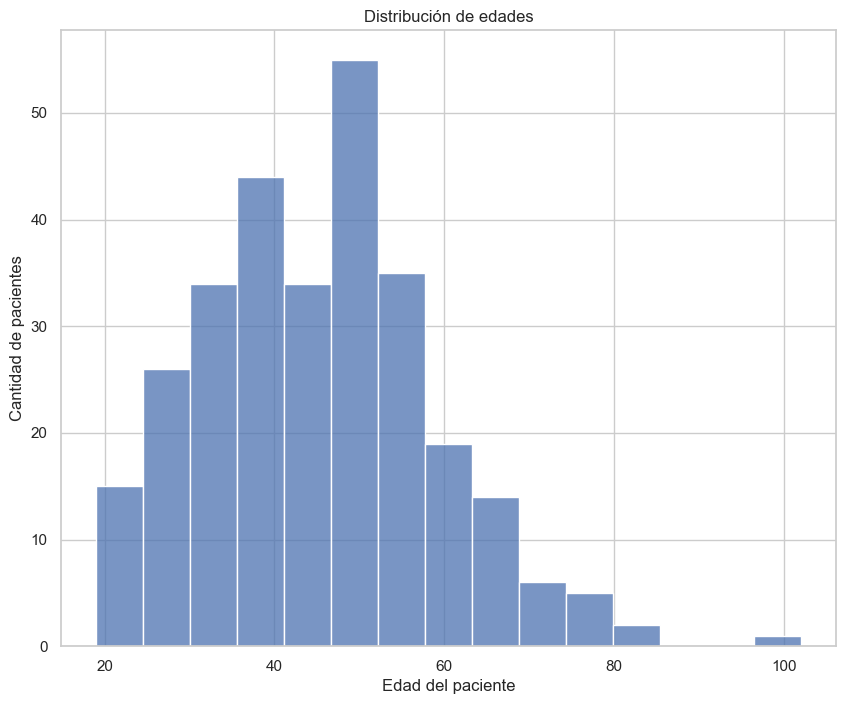

In [51]:
plt.figure(figsize=(10,8))
sns.histplot(df["Edad"])
plt.title("Distribución de edades")
plt.ylabel("Cantidad de pacientes")
plt.xlabel("Edad del paciente")
plt.show()

### Ejercicio 3: Dispersión y Outliers (Boxplot)
Crea un gráfico de caja (boxplot) que muestre el `IMC` agrupado por `Sexo`. Esto nos ayudará a ver si hay diferencias en la distribución del Índice de Masa Corporal entre hombres y mujeres, y si existen valores atípicos (outliers).
*Hint: `sns.boxplot(data=df, x='...', y='...')`*

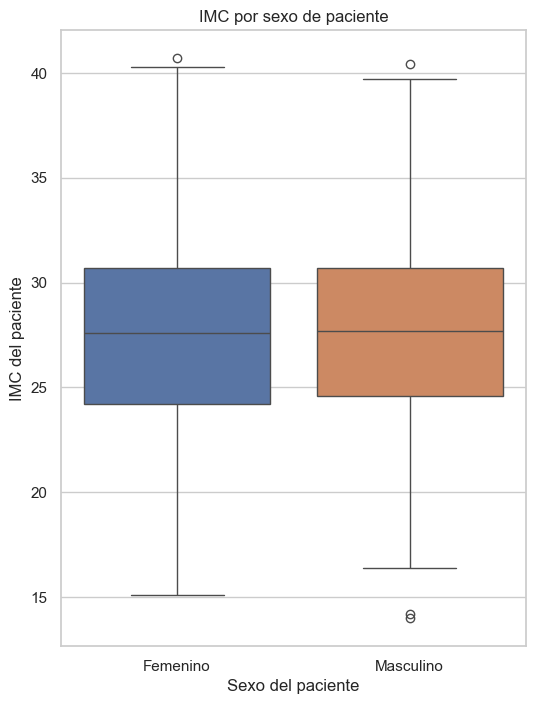

In [66]:
plt.figure(figsize=(6,8))
sns.boxplot(data = df, x='Sexo', y='IMC', hue='Sexo')
plt.title("IMC por sexo de paciente")
plt.ylabel("IMC del paciente")
plt.xlabel("Sexo del paciente")
plt.show()

### Ejercicio 4: Relación entre variables (Scatter Plot)
Crea un gráfico de dispersión (scatter plot) para observar si existe alguna relación visual entre el `IMC` (eje X) y la `Glucosa_Ayunas` (eje Y).
*Hint: `plt.scatter()` o `sns.scatterplot()`*

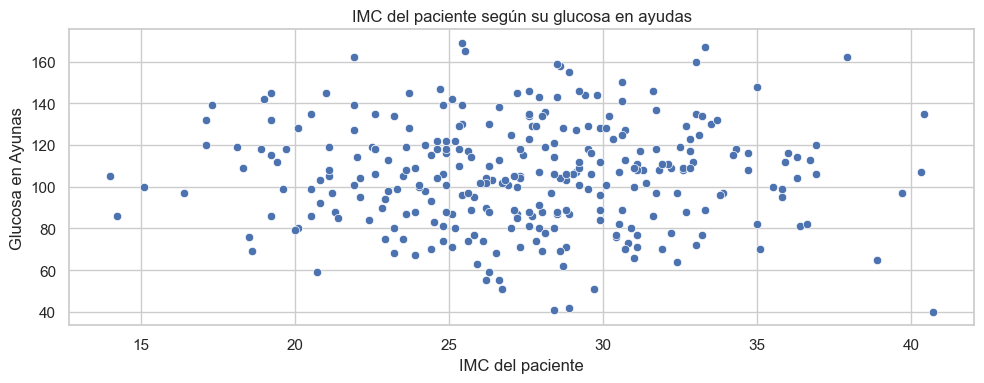

In [77]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='IMC', y='Glucosa_Ayunas')
#sns.regplot(data=df, x='Glucosa_Ayunas', y="IMC") #Grafico con regresion lineal
plt.title("IMC del paciente según su glucosa en ayudas")
plt.ylabel("Glucosa en Ayunas")
plt.xlabel("IMC del paciente")
plt.tight_layout()
plt.show()